# Classify CLOSED/OPEN EYE with Keras and MobileNet

## Step 1: Data Preprocessing

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

DATASET_PATH = "dataset/eye-dataset/"  # Included 3 folders: train, val, test
IMG_SIZE = 128 #Change: Increase IMG_SIZE        
BATCH_SIZE = 128 #Change: Increase BATCH_SIZE

# 1. Load Training
train_ds = tf.keras.utils.image_dataset_from_directory(
  os.path.join(DATASET_PATH, 'train'),
  seed=42,
  image_size=(IMG_SIZE, IMG_SIZE),
  batch_size=BATCH_SIZE)

# 2. Load Validation
val_ds = tf.keras.utils.image_dataset_from_directory(
  os.path.join(DATASET_PATH, 'val'),
  seed=42,
  image_size=(IMG_SIZE, IMG_SIZE),
  batch_size=BATCH_SIZE)

# 3. Load Test
test_ds = tf.keras.utils.image_dataset_from_directory(
  os.path.join(DATASET_PATH, 'test'),
  seed=42,
  image_size=(IMG_SIZE, IMG_SIZE),
  batch_size=BATCH_SIZE)

class_names = train_ds.class_names
print(f"\nList of Labels found by Keras: {class_names}")

Found 139804 files belonging to 2 classes.
Found 27961 files belonging to 2 classes.
Found 6991 files belonging to 2 classes.

List of Labels found by Keras: ['closed', 'open']


In [2]:
AUTOTUNE = tf.data.AUTOTUNE

# 1. Khởi tạo Normalization (Chuẩn hoá)
normalization_layer = tf.keras.layers.Rescaling(1./255)

# 2. Định nghĩa các Layer Augmentation (Chỉ áp dụng cho tập Train)
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal"),    # Lật ngang ảnh (Mắt lật trái/phải hiển nhiên vẫn là mắt)
  tf.keras.layers.RandomRotation(0.1),         # Xoay ảnh một góc tối đa 10% (Tạo góc nhìn hơi nghiêng)
  tf.keras.layers.RandomZoom(0.1),             # Phóng to/thu nhỏ tối đa 10%
])

# 3. Áp dụng cho tập Train
# Quan trọng: Map Normalization -> Cache -> Map Augmentation -> Prefetch
# Lý do: Chúng ta chỉ cache ảnh đã được chuẩn hóa để tăng tốc độ. Sau khi cache mới gọi transform 
# để mỗi Epoch hàm Augmentation sẽ tạo ra một biến thể ngẫu nhiên hoàn toàn mới!
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.cache()
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)

# 4. Tập Val và Test chỉ cần Normalize, tuyệt đối không Transform
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Step 2: Load the MobileNetV2 Structure

In [3]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Transfer Learning:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

# Unfreeze the last 20 layers to learn the fine details of "Eyelashes" and "Irises"
for layer in base_model.layers[-20:]:
    layer.trainable = True

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x) ##Change: 0.4 -> 0.5
x = Dense(32, activation='relu', kernel_regularizer=l2(0.01))(x) ##Change: Add L2
outputs = Dense(1, activation='sigmoid')(x) # sigmoid since the output is binary: 0 or 1

model = Model(inputs, outputs)

model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        40,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,299,009 (8.77 MB)

 Trainable params: 1,247,105 (4.76 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

## Step 3: Do Training Model

In [4]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_blink_mobilenet.h5", save_best_only=True)

##Change: Add ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)

EPOCHS = 20
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.9385 - loss: 0.6089

1093/1093 ━━━━━━━━━━━━━━━━━━━━ 251s 226ms/step - accuracy: 0.9639 - loss: 0.4167 - val_accuracy: 0.9230 - val_loss: 0.3027 - learning_rate: 1.0000e-04
Epoch 2/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.9774 - loss: 0.1418

1093/1093 ━━━━━━━━━━━━━━━━━━━━ 241s 221ms/step - accuracy: 0.9794 - loss: 0.1121 - val_accuracy: 0.9800 - val_loss: 0.0813 - learning_rate: 1.0000e-04
Epoch 3/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 236s 216ms/step - accuracy: 0.9827 - loss: 0.0595 - val_accuracy: 0.9682 - val_loss: 0.0951 - learning_rate: 1.0000e-04
Epoch 4/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.9835 - loss: 0.0493

1093/1093 ━━━━━━━━━━━━━━━━━━━━ 233s 213ms/step - accuracy: 0.9844 - loss: 0.0465 - val_accuracy: 0.9768 - val_loss: 0.0660 - learning_rate: 1.0000e-04
Epoch 5/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9859 - loss: 0.0422

1093/1093 ━━━━━━━━━━━━━━━━━━━━ 229s 209ms/step - accuracy: 0.9865 - loss: 0.0405 - val_accuracy: 0.9808 - val_loss: 0.0538 - learning_rate: 1.0000e-04
Epoch 6/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.9861 - loss: 0.0392

...

1093/1093 ━━━━━━━━━━━━━━━━━━━━ 231s 211ms/step - accuracy: 0.9898 - loss: 0.0302 - val_accuracy: 0.9864 - val_loss: 0.0386 - learning_rate: 1.0000e-04
Epoch 10/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9895 - loss: 0.0299

1093/1093 ━━━━━━━━━━━━━━━━━━━━ 236s 216ms/step - accuracy: 0.9900 - loss: 0.0285 - val_accuracy: 0.9875 - val_loss: 0.0377 - learning_rate: 1.0000e-04
Epoch 11/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 234s 214ms/step - accuracy: 0.9909 - loss: 0.0268 - val_accuracy: 0.9734 - val_loss: 0.0876 - learning_rate: 1.0000e-04
Epoch 12/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9907 - loss: 0.0262
Epoch 12: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 233s 213ms/step - accuracy: 0.9914 - loss: 0.0251 - val_accuracy: 0.9852 - val_loss: 0.0400 - learning_rate: 1.0000e-04
Epoch 13/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 233s 213ms/step - accuracy: 0.9934 - loss: 0.0199 - val_accuracy: 0.9859 - val_loss: 0.0399 - learning_rate: 5.0000e-05
Epoch 14/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.9931 - loss: 0.0207

1093/1093 ━━━━━━━━━━━━━━━━━━━━ 241s 220ms/step - accuracy: 0.9937 - loss: 0.0190 - val_accuracy: 0.9871 - val_loss: 0.0373 - learning_rate: 5.0000e-05
Epoch 15/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.9939 - loss: 0.0183

1093/1093 ━━━━━━━━━━━━━━━━━━━━ 245s 223ms/step - accuracy: 0.9941 - loss: 0.0181 - val_accuracy: 0.9878 - val_loss: 0.0365 - learning_rate: 5.0000e-05
Epoch 16/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 242s 221ms/step - accuracy: 0.9943 - loss: 0.0175 - val_accuracy: 0.9870 - val_loss: 0.0397 - learning_rate: 5.0000e-05
Epoch 17/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.9943 - loss: 0.0174
Epoch 17: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 237s 217ms/step - accuracy: 0.9947 - loss: 0.0165 - val_accuracy: 0.9880 - val_loss: 0.0389 - learning_rate: 5.0000e-05
Epoch 18/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9951 - loss: 0.0152

1093/1093 ━━━━━━━━━━━━━━━━━━━━ 232s 212ms/step - accuracy: 0.9955 - loss: 0.0141 - val_accuracy: 0.9901 - val_loss: 0.0338 - learning_rate: 2.5000e-05
Epoch 19/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 234s 214ms/step - accuracy: 0.9956 - loss: 0.0135 - val_accuracy: 0.9881 - val_loss: 0.0402 - learning_rate: 2.5000e-05
Epoch 20/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.9960 - loss: 0.0137
Epoch 20: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 240s 220ms/step - accuracy: 0.9960 - loss: 0.0130 - val_accuracy: 0.9895 - val_loss: 0.0363 - learning_rate: 2.5000e-05


## Step 4: Evaluation

55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 142ms/step - accuracy: 0.9907 - loss: 0.0287

Last Accuracy on Test: 99.07%


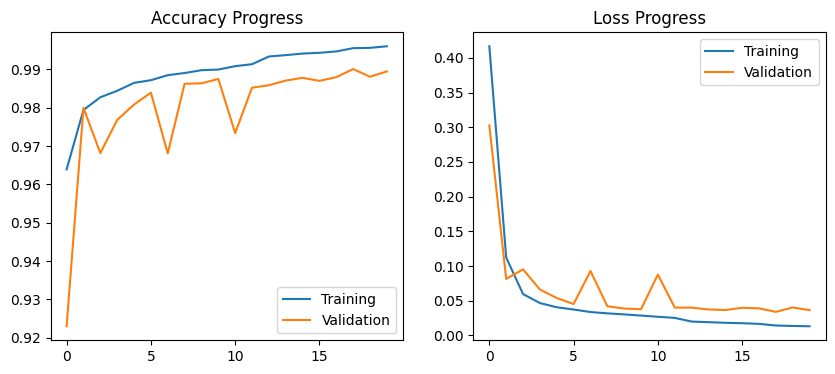

In [5]:
loss, acc = model.evaluate(test_ds)
print(f"\nLast Accuracy on Test: {acc*100:.2f}%")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy Progress')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss Progress')
plt.legend()
plt.show()

## Step 5: ONNX Export

In [6]:
import tf2onnx

spec = (tf.TensorSpec((None, IMG_SIZE, IMG_SIZE, 3), tf.float32, name="input"),)
output_path = "mobilenet_eye_blink.onnx"

model_proto, _ = tf2onnx.convert.from_keras(model, input_signature=spec, opset=13, output_path=output_path)
output_names = [n.name for n in model_proto.graph.output]
print(f"\nSuccessfully exported to ONNX! Output file: {output_path}")
print(f"Please note down the Input Name: input, Output Name: {output_names}")

I0000 00:00:1776059054.414682  610320 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1776059054.415013  610320 single_machine.cc:376] Starting new session
I0000 00:00:1776059054.876134  610320 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1776059054.876212  610320 single_machine.cc:376] Starting new session



Successfully exported to ONNX! Output file: mobilenet_eye_blink.onnx
Please note down the Input Name: input, Output Name: ['dense_1']
